# Titanic Survival Prediction
### End-to-end Machine Learning Pipeline

The Titanic dataset is one of the most well-known datasets in data science - but the goal here is not to simply achieve a high accuracy score. 
The goal is to build a **thoughtful, well-documented ML pipeline** that 
demonstrates analytical thinking, deliberate feature engineering, and 
interpretable modelling decisions.

**Dataset:** Kaggle Titanic - 891 passengers, 12 features  
**Target:** Survived (0 = Did not survive, 1 = Survived)  
**Approach:** EDA -> Feature Engineering -> Preprocessing -> Modelling -> Explainability


## Environment Setup

Importing core libraries for data manipulation, numerical computation, 
and visualisation. All plots are saved as PNG files for reproducibility 
and portfolio documentation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

Loading the raw Titanic dataset. Before any analysis, the first step is 
always to load and verify the data is intact - correct shape, expected 
columns, and no silent load errors.

In [2]:
data = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df = pd.DataFrame(data)

### First Look

Inspecting the first and last few rows to get an immediate sense of 
the data structure - what features exist, what the values look like, 
and whether anything looks immediately unusual.

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Shape and Column Inventory

Verifying dimensions and column names before any transformation. 
This is a simple but critical checkpoint - confirming we have the 
expected 891 rows and 12 columns before proceeding.

In [6]:
df.shape

(891, 12)

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### Data Types and Memory

Understanding data types matters because it determines which 
preprocessing steps are needed - numeric features need scaling, 
categorical features need encoding. Mixed types or unexpected 
object columns here signal cleaning work ahead.

In [8]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Statistical Summary

Descriptive statistics for all numeric features. Key things to look 
for here:
- **Min/max outliers** - Fare has a known extreme right tail
- **Mean vs median gaps** - signals skewness
- **Count vs total rows** - any count below 891 indicates missing values

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Boxplot Overview

A quick visual scan of all numeric distributions simultaneously. 
Boxplots are particularly useful at this stage for spotting outliers 
before making imputation or scaling decisions.

<AxesSubplot:>

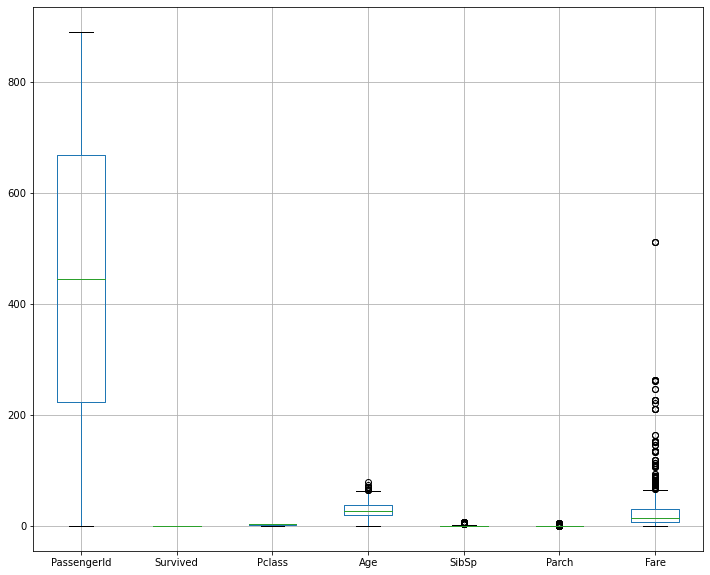

In [11]:
df.boxplot(figsize=(12,10), fontsize='medium',)

### Missing Value Analysis

Identifying missing data before any transformation is non-negotiable.
Imputation decisions - whether to use mean, median, mode, or model-based
imputation - depend on both the percentage missing and the feature's
relationship with the target variable.

          Missing Count  Missing %
Cabin               687       77.1
Age                 177       19.9
Embarked              2        0.2


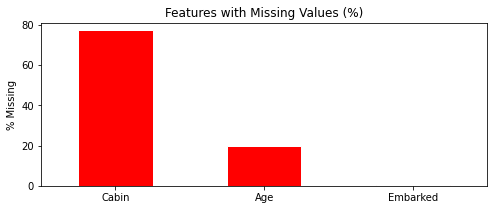

In [12]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_df)

# Visual
fig, ax = plt.subplots(figsize=(8, 3))
missing_df['Missing %'].plot(kind='bar', color='red',edgecolor='white', ax=ax)
ax.set_title('Features with Missing Values (%)')
ax.set_ylabel('% Missing')
plt.xticks(rotation=0)
plt.savefig('eda_04_missing_values.png', dpi=100)

## Target Variable Analysis

Before any feature analysis, understanding the target variable is 
the most important step. Class imbalance in the target directly affects 
model evaluation strategy - a heavily imbalanced target can produce 
a model that appears accurate but simply predicts the majority class.

In [13]:
df["Survived"].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [14]:
df["Survived"].value_counts(normalize=True)

0    0.616162
1    0.383838
Name: Survived, dtype: float64

In [15]:
survival_counts = df["Survived"].value_counts()
survival_pct = df["Survived"].value_counts(normalize=True) * 100

print(f"Did not survive : {survival_counts[0]} ({survival_pct[0]:.1f}%)")
print(f"Survived        : {survival_counts[1]} ({survival_pct[1]:.1f}%)")
print(f"Total passengers: {survival_counts.sum()}")

Did not survive : 549 (61.6%)
Survived        : 342 (38.4%)
Total passengers: 891


### Survival Distribution

**Finding:** 61.6% of passengers did not survive (549), 38.4% survived (342).  
This is a **moderate imbalance** - worth monitoring during model evaluation 
but not severe enough to require resampling techniques like SMOTE at this stage. 
Evaluation will prioritise F1-score and ROC-AUC over raw accuracy.

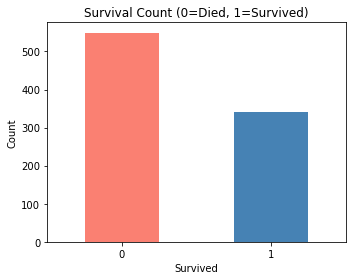

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
df["Survived"].value_counts().plot(kind="bar", color=["salmon", "steelblue"], ax=ax)
ax.set_title("Survival Count (0=Died, 1=Survived)")
ax.set_xlabel("Survived")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_01_survived_count.png", dpi=100)

In [17]:
plt.close()

## Univariate Feature Analysis

Analysing each feature independently before looking at relationships 
with the target. The goal here is to understand distributions, spot 
skewness, and identify missing values - all of which inform preprocessing 
decisions later.

### Numeric Features - Age and Fare

Two continuous features with very different characteristics:
- **Age** - roughly normal distribution but with 177 missing values (19.9% of data). 
  Imputation strategy will be decided after examining survival patterns by age group.
- **Fare** - heavily right-skewed with extreme outliers. 
  Log transformation will likely be needed before modelling.

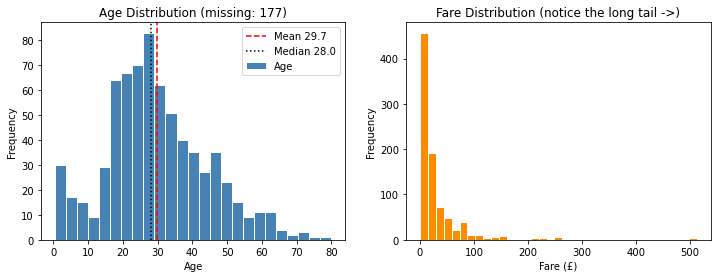

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Age — continuous, has missing values
df["Age"].plot(kind="hist", bins=25, color="steelblue",edgecolor="white", ax=axes[0])
axes[0].axvline(df["Age"].mean(),   color="red",   linestyle="--", label=f"Mean {df['Age'].mean():.1f}")
axes[0].axvline(df["Age"].median(), color="black", linestyle=":",  label=f"Median {df['Age'].median():.1f}")
axes[0].legend()
axes[0].set_title(f"Age Distribution (missing: {df['Age'].isnull().sum()})")
axes[0].set_xlabel("Age")
 
# Fare — continuous, right-skewed
df["Fare"].plot(kind="hist", bins=35, color="darkorange",edgecolor="white", ax=axes[1])
axes[1].set_title("Fare Distribution (notice the long tail ->)")
axes[1].set_xlabel("Fare (£)")
plt.savefig("eda_02_numeric_histograms.png", dpi=100)

### Categorical Features - Sex, Pclass, Embarked

Three categorical features that are expected to have strong relationships 
with survival based on domain knowledge of the disaster:
- **Sex** - "women and children first" protocol was reportedly followed
- **Pclass** - ticket class as a proxy for socioeconomic status
- **Embarked** - port of embarkation (Southampton, Cherbourg, Queenstown)

Distribution counts here establish the baseline before cross-tabulating 
with survival in the next section.

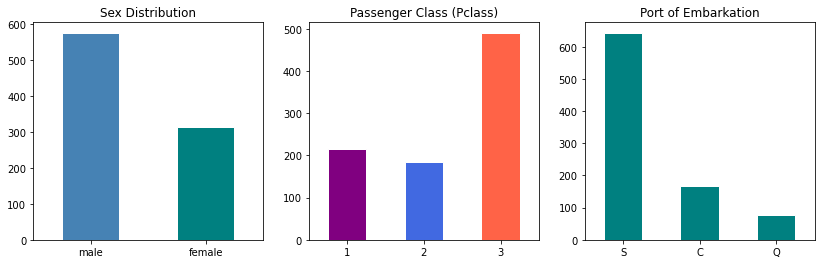

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
 
# Sex
df["Sex"].value_counts().plot(kind="bar", color=["steelblue", "teal"],ax=axes[0], edgecolor="white")
axes[0].set_title("Sex Distribution")
axes[0].tick_params(axis="x", rotation=0)
 
# Pclass — ordinal (order matters: 1 > 2 > 3)
df["Pclass"].value_counts().sort_index().plot(kind="bar",color=["purple", "royalblue", "tomato"], ax=axes[1], edgecolor="white")
axes[1].set_title("Passenger Class (Pclass)")
axes[1].tick_params(axis="x", rotation=0)
 
# Embarked — nominal (no order)
df["Embarked"].value_counts().plot(kind="bar", color="teal",ax=axes[2], edgecolor="white")
axes[2].set_title("Port of Embarkation")
axes[2].tick_params(axis="x", rotation=0)
plt.savefig("eda_03_categorical_bars.png", dpi=100)

In [20]:
plt.close()

## Bivariate Analysis - Survival by Feature

Univariate analysis told us what the data looks like.
Bivariate analysis tells us what actually matters for survival.

This section cross-tabulates each key feature against the target variable
to identify predictive signals. These findings directly inform which
features to prioritise in engineering and modelling.

### Survival by Sex

Sex is expected to be the strongest single predictor in this dataset.
The evacuation protocol - women and children first - was reportedly
followed during the Titanic disaster.

We plot both raw counts and survival *rates* because group sizes differ
(more male passengers overall). Rates give the honest comparison.

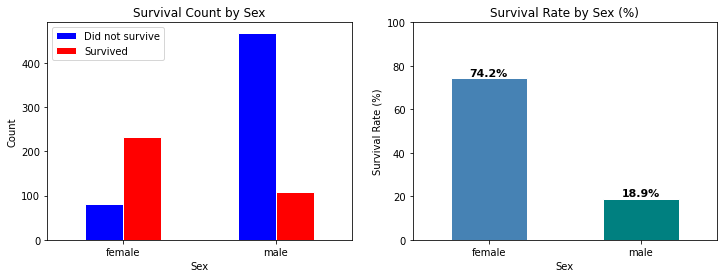

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left - counts grouped by sex
survival_by_sex = df.groupby(['Sex', 'Survived']).size().unstack()
survival_by_sex.plot(kind='bar', color=['blue', 'red'],ax=axes[0], edgecolor='white')
axes[0].set_title('Survival Count by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Did not survive', 'Survived'])

# Right - survival RATE by sex (more honest than raw counts)
survival_rate_sex = df.groupby('Sex')['Survived'].mean() * 100
survival_rate_sex.plot(kind='bar', color=['steelblue', 'teal'],ax=axes[1], edgecolor='white')
axes[1].set_title('Survival Rate by Sex (%)')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 100)

# Annotate bars with percentage
for i, v in enumerate(survival_rate_sex):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.savefig('eda_05_survival_by_sex.png', dpi=100)


In [22]:
plt.close()

### Survival by Passenger Class

Pclass is a proxy for socioeconomic status and, critically, physical
proximity to lifeboats - 1st class cabins were on higher decks with
faster lifeboat access.

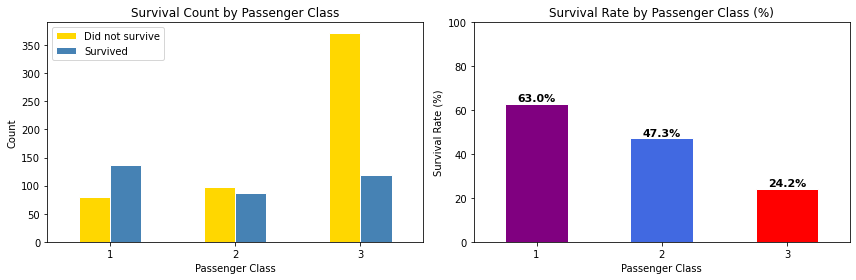

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left - counts
survival_by_class = df.groupby(['Pclass', 'Survived']).size().unstack()
survival_by_class.plot(kind='bar', color=['gold', 'steelblue'],ax=axes[0], edgecolor='white')
axes[0].set_title('Survival Count by Passenger Class')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Did not survive', 'Survived'])

# Right - survival rate
survival_rate_class = df.groupby('Pclass')['Survived'].mean() * 100
survival_rate_class.plot(kind='bar',color=['purple', 'royalblue', 'red'],ax=axes[1], edgecolor='white')
axes[1].set_title('Survival Rate by Passenger Class (%)')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 100)

for i, v in enumerate(survival_rate_class):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_06_survival_by_pclass.png', dpi=100)


In [24]:
plt.close()

### Survival by Sex and Pclass Combined

Individual features tell part of the story. Their interaction tells
the full story. A heatmap of survival rate across Sex * Pclass reveals
whether the class effect holds within each gender - and by how much.

This interaction is a candidate for an engineered feature in the
next section.

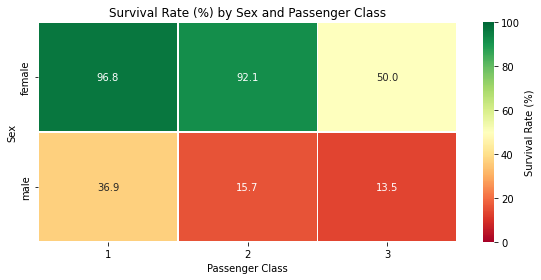

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))

# Pivot table - survival rate by Sex and Pclass
pivot = df.pivot_table(values='Survived',
                        index='Sex',
                        columns='Pclass',
                        aggfunc='mean') * 100

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=100,
            cbar_kws={'label': 'Survival Rate (%)'})
ax.set_title('Survival Rate (%) by Sex and Passenger Class')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Sex')

plt.tight_layout()
plt.savefig('eda_07_survival_heatmap_sex_pclass.png', dpi=100)


In [26]:
plt.close()

### Age Distribution by Survival Status

Overlapping histograms allow direct comparison of the age profiles
of survivors vs non-survivors. The "children first" element of
evacuation protocol should be visible as higher survival density
in younger age groups.

**Imputation note:** 177 Age values are missing. Before plotting,
missing values are dropped - this is valid for visualisation but
imputation will be required before modelling.

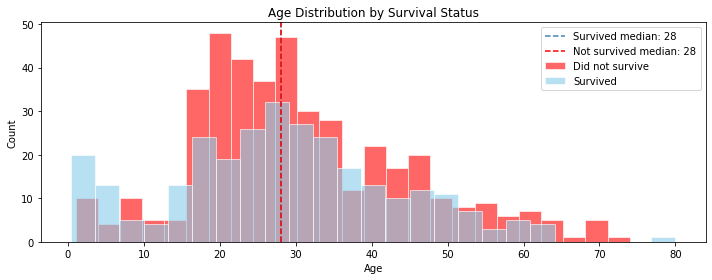

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))

# Separate survived and not survived
survived = df[df['Survived'] == 1]['Age'].dropna()
not_survived = df[df['Survived'] == 0]['Age'].dropna()

ax.hist(not_survived, bins=25, alpha=0.6, color='red',edgecolor='white', label='Did not survive')
ax.hist(survived, bins=25, alpha=0.6, color='skyblue',edgecolor='white', label='Survived')

ax.axvline(survived.median(), color='steelblue', linestyle='--',linewidth=1.5, label=f'Survived median: {survived.median():.0f}')
ax.axvline(not_survived.median(), color='red', linestyle='--',linewidth=1.5, label=f'Not survived median: {not_survived.median():.0f}')

ax.set_title('Age Distribution by Survival Status')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig('eda_08_age_by_survival.png', dpi=100)

In [28]:
plt.close()

### Bivariate analysis complete. Key findings:

- **Sex:** Strongest predictor - female survival rate ~74% vs male ~19%
- **Pclass:** Clear socioeconomic gradient - 1st class ~63%, 3rd class ~24%
- **Sex × Pclass interaction:** 1st class female ~97% survival,
  3rd class male ~13% - a powerful combined signal
- **Age:** Children show higher survival density - supports
  creating an IsChild binary feature


- **Cabin:** 687 missing (77.1%) - too many to impute, will engineer HasCabin binary flag
- **Age:** 177 missing (19.9%) - will impute using title-based grouped medians
- **Embarked:** 2 missing (0.2%) - will impute with mode (Southampton)

## Feature Engineering

Raw features rarely tell the full story. Feature engineering extracts
and creates new signals that the model can use more effectively.

Every engineered feature below is grounded in either:
- **Domain knowledge** - what we know about the Titanic disaster
- **Statistical evidence** - patterns observed in the EDA above

Features engineered:
- `Title` - extracted from Name; proxy for age, gender, and social status
- `FamilySize` - SibSp + Parch + 1; captures travelling group context
- `IsAlone` - binary flag for solo travellers
- `IsChild` - binary flag for passengers under 12
- `Fare_log` - log transformation of Fare to reduce skewness
- `HasCabin` - binary flag for whether cabin was recorded
- `Deck` - first letter of Cabin; proxy for deck level and class

In [29]:
df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)\.', expand=False)
print(df['Title'].value_counts())

Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Col           2
Mlle          2
Lady          1
Don           1
Jonkheer      1
Sir           1
Capt          1
Ms            1
Countess      1
Mme           1
Name: Title, dtype: int64


In [30]:
rare_titles = ['Dr', 'Rev', 'Mlle', 'Col', 'Major', 'Don', 'Lady', 'Jonkheer', 'Ms', 'Countess', 'Mme', 'Sir', 'Capt']

df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Ms' : 'Miss', 'Mme' : 'Mrs'})

print(df['Title'].value_counts())

Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: Title, dtype: int64


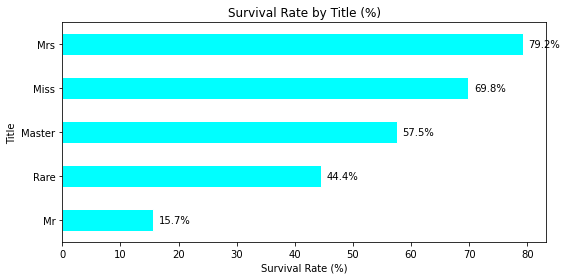

In [31]:
fig, ax = plt.subplots(figsize=(8,4))
title_survival = df.groupby('Title')['Survived'].mean() * 100
title_survival.sort_values().plot(kind= 'barh', color = 'cyan', edgecolor = 'white', ax=ax)

ax.set_title('Survival Rate by Title (%)')
ax.set_xlabel('Survival Rate (%)')

for i, v in enumerate(title_survival.sort_values()):
    ax.text(v+1, i, f'{v:.1f}%', va = 'center', fontsize = 10)
    
plt.tight_layout()
plt.savefig('fe_01_survival_by_title.png', dpi = 100)


In [32]:
plt.close()

In [33]:
title_age_medians = df.groupby('Title')['Age'].median()
print(title_age_medians)

# Impute missing ages
df['Age'] = df.apply(
    lambda row: title_age_medians[row['Title']]
    if pd.isnull(row['Age']) else row['Age'],
    axis=1
)

# Verify no missing ages remain
print(f"Missing ages after imputation: {df['Age'].isnull().sum()}")

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      44.5
Name: Age, dtype: float64
Missing ages after imputation: 0


In [35]:
# Family size = siblings/spouses + parents/children + self
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# IsAlone binary flag
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

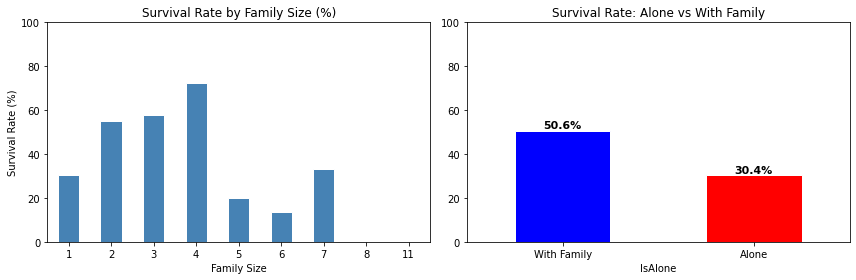

In [36]:
# Plot survival by family size
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

family_survival = df.groupby('FamilySize')['Survived'].mean() * 100
family_survival.plot(kind='bar', color='steelblue',edgecolor='white', ax=axes[0])
axes[0].set_title('Survival Rate by Family Size (%)')
axes[0].set_xlabel('Family Size')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 100)

alone_survival = df.groupby('IsAlone')['Survived'].mean() * 100
alone_survival.plot(kind='bar', color=['blue', 'red'],edgecolor='white', ax=axes[1])
axes[1].set_title('Survival Rate: Alone vs With Family')
axes[1].set_xticklabels(['With Family', 'Alone'], rotation=0)
axes[1].set_ylim(0, 100)
for i, v in enumerate(alone_survival):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center',fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fe_02_family_survival.png', dpi=100)

In [38]:
plt.close()

In [39]:
# IsChild - passengers under 12
df['IsChild'] = (df['Age'] < 12).astype(int)

print(f"Children: {df['IsChild'].sum()}")
print(f"Child survival rate: {df[df['IsChild']==1]['Survived'].mean()*100:.1f}%")
print(f"Adult survival rate: {df[df['IsChild']==0]['Survived'].mean()*100:.1f}%")

Children: 72
Child survival rate: 56.9%
Adult survival rate: 36.8%


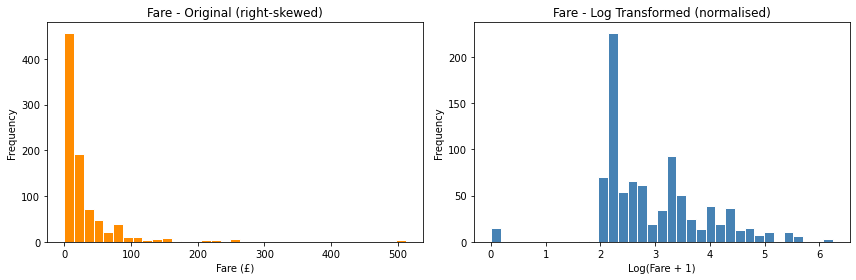

In [40]:
# Log transform - add 1 to handle any zero fares
df['Fare_log'] = np.log1p(df['Fare'])

# Compare distributions before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Fare'].plot(kind='hist', bins=35, color='darkorange',edgecolor='white', ax=axes[0])
axes[0].set_title('Fare - Original (right-skewed)')
axes[0].set_xlabel('Fare (£)')

df['Fare_log'].plot(kind='hist', bins=35, color='steelblue',edgecolor='white', ax=axes[1])
axes[1].set_title('Fare - Log Transformed (normalised)')
axes[1].set_xlabel('Log(Fare + 1)')

plt.tight_layout()
plt.savefig('fe_03_fare_log_transform.png', dpi=100)

In [41]:
plt.close()